# Анализ данных социальных сетей

Применение инструментов для сбора и анализа данных социальных сетей рассматривается на примере сети [ВКонтакте](https://vk.com/).<br/>
Сбор данных из социальных сетей осуществляется посредством открытого API.<br/>
[Документация](https://dev.vk.com/api/getting-started) по работе с API ВКонтакте.<br/>
Для работы с VK API на Python есть различные библиотеки: vk, vk_api, aiovk. <br/>
vk_api имеет более развернутую [документацию](https://vk-api.readthedocs.io/en/latest/) на русском языке и расширенный функционал.<br/>
Устанавливается данная библиотека стандартной командой:


In [7]:
%pip install vk_api
%pip install psycopg2


   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ------------------- -------------------- 1.3/2.7 MB 4.2 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.7 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 4.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pickle
import time
from random import randint

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import psycopg2
import tqdm
import vk_api
from IPython.display import clear_output

По логину и паролю не работает. Токен брать здесь: https://vkhost.github.io/

In [ ]:
vkApiSession = vk_api.VkApi(
    token="vk1.a.6FpRUImwoi_2BWZrUYPqVcdpXrD-00Y8v8opm2S04Bgd9jyQNImGTZ1mBzmuXKJ2zxJdOfCQZZUH5c_C_-_y3B7EhVRu1T0CM8QHJzZuDAkg_F0OUq-slgJI3YEJZxBuGko6VBe5nF3ehDMZcu3Qq_k727F7qQLIMNzh0qdWkLeZdI48Esr_kjDKw86BQVscS8UdudUiU9WvFFzb1QLVew"
)

vkU = vkApiSession.get_api()

In [ ]:
def get_connection():
    """Создание подключения к базе данных"""
    try:
        conn = psycopg2.connect(
            host="localhost",
            port="5432",
            database="diploma_db",
            user="moliksey",
            password="diploma",  # Для работы с результатами как со словарями
        )
        print("✅ Подключение к PostgreSQL успешно установлено")
        return conn
    except Exception as e:
        print(f"❌ Ошибка подключения: {e}")
        return None


# Пример использования
conn = get_connection()
cursor = conn.cursor()

✅ Подключение к PostgreSQL успешно установлено


In [196]:
conn.rollback()

In [16]:
cursor.execute("select count(*) from sub")
cursor.fetchone()

(1966948,)

In [7]:
tools = vk_api.VkTools(vkU)

In [159]:
networks = [
    ("VKontakte",),
    ("X(Twitter)",),
]

# Вставляем, избегая дубликатов
cursor.executemany(
    """
        INSERT INTO network (network_name)
        VALUES (%s)
        ON CONFLICT (network_name) DO NOTHING
    """,
    networks,
)
conn.commit()

In [55]:
conn.rollback()

In [161]:
cursor.execute(
    """
                INSERT INTO creator (external_id, is_person, network_type)
                VALUES (%s, %s, %s)
                ON CONFLICT (external_id)
                DO UPDATE SET id = creator.id
                RETURNING id
            """,
    (365075119, True, 1),
)
s = cursor.fetchone()[0]
s

1

In [9]:
cursor.execute("SELECT id from network where network_name='VKontakte'")
vk_id = cursor.fetchone()[0]

In [10]:
def get_users_to_process(limit=None, offset=0, isperson=True):
    """Получает пользователей из базы для обработки"""
    if isperson:
        query = """
                        SELECT c.id, c.external_id
                        FROM creator c
                        WHERE c.network_type = %s
                        AND c.is_person =  true
                        ORDER BY c.id
                        LIMIT %s OFFSET %s
                        """
    else:
        query = """
                        SELECT c.id, c.external_id
                        FROM creator c
                        WHERE c.network_type = %s
                        ORDER BY c.id
                        LIMIT %s OFFSET %s
                        """
    cursor.execute(query, (vk_id, limit or 100, offset))
    if limit:
        new_offset = offset + limit
    else:
        new_offset = offset + 100
    return cursor.fetchall(), new_offset

In [ ]:
user = "365075119"


def save_creators(cursor_self, frends, their_friend):
    try:
        # 1. Вставляем всех создателей (основного + друзей)
        all_external_ids = frends
        creators_data = [(ext_id, True, vk_id) for ext_id in all_external_ids]

        # Вставляем и получаем mapping: external_id -> creator_id
        creator_mapping = {}

        for external_id, is_person, network_type in creators_data:
            cursor_self.execute(
                """
                INSERT INTO creator (external_id, is_person, network_type)
                VALUES (%s, %s, %s)
                ON CONFLICT (external_id)
                DO UPDATE SET id = creator.id
                RETURNING id, external_id
            """,
                (external_id, is_person, network_type),
            )

            creator_id, ext_id = cursor_self.fetchone()
            creator_mapping[ext_id] = creator_id
        conn.commit()
        try:
            cursor.execute(
                """
              select id from creator where external_id=%s
          """,
                (their_friend),
            )
            main_creator_id = cursor.fetchone()[0]
        except Exception:
            conn.rollback()
            cursor_self.execute(
                """
                INSERT INTO creator (external_id, is_person, network_type)
                VALUES (%s, %s, %s)
                ON CONFLICT (external_id)
                DO UPDATE SET id = creator.id
                RETURNING id
            """,
                (their_friend, True, vk_id),
            )
            main_creator_id = cursor_self.fetchone()[0]
        # 2. Подготавливаем связи для executemany
        connections_data = []

        for friend_ext_id in frends:
            friend_creator_id = creator_mapping.get(friend_ext_id)
            if friend_creator_id:
                # Два направления
                connections_data.append((main_creator_id, friend_creator_id))  # друг → основной
                connections_data.append((friend_creator_id, main_creator_id))  # основной → друг

        # 3. Пакетная вставка связей
        if connections_data:
            cursor_self.executemany(
                """
                INSERT INTO sub (contentmaker, subscriber)
                VALUES (%s, %s)
                ON CONFLICT (contentmaker, subscriber) DO NOTHING
            """,
                connections_data,
            )

        conn.commit()

        return main_creator_id, [creator_mapping.get(fid) for fid in frends]

    except Exception as e:
        conn.rollback()
        print(f"❌ Ошибка: {e}")
        return None, []


# Получаем всех друзей и друзей друзей
def get_groups_users(cursor_self, tools, offset=0):
    cursor_self.execute(
        """
        SELECT count(*)
        FROM creator c
        WHERE c.network_type = %s
    """,
        (vk_id,),
    )
    lenth = cursor.fetchone()[0]
    new_offset = offset

    # Прогресс-бар для основного цикла
    with tqdm.tqdm(total=lenth, initial=offset, desc="Processing groups") as pbar:
        while new_offset < lenth:
            try:
                peoples, new_offset = get_users_to_process(offset=new_offset, isperson=False)
                # Прогресс-бар для обработки пользователей в текущем батче
                for creator_id, creator_ext_id in tqdm.tqdm(
                    peoples, desc=f"Batch {offset}-{new_offset}", leave=False
                ):
                    try:
                        friends_out = tools.get_all(
                            "friends.get", 5000, {"user_id": creator_ext_id}
                        )
                        save_creators(cursor_self, friends_out["items"], creator_id)
                        time.sleep(1)
                    except Exception as e:
                        if "This profile is private" not in str(e):
                            print(f"Error with processing batch: {e}")
                            print(new_offset)

                # Обновляем основной прогресс-бар
                pbar.update(len(peoples))
            except Exception as e:
                print(f"Error with processing batch: {e}")
                time.sleep(1)
                print(new_offset)

    return new_offset


# offset_user=0
# print("start_getting_friends")
# offset_user = get_groups_users(cursor, tools, offset=offset_user)
# print("frends_got")

In [12]:
cursor.execute("SELECT * from creator")
len(cursor.fetchall())

617979

In [ ]:
conn.commit()

In [183]:
offset_user = 100

In [199]:
offset_user = get_groups_users(cursor, tools, offset=offset_user)

Processing groups:   0%|          | 100/366343 [00:00<?, ?it/s]

Error with processing batch: Could not load items: [{'method': 'friends.get', 'error_code': 9, 'error_msg': 'Flood control', 'view': None, 'i18n_title': None}]
200


Error with processing batch: Could not load items: [{'method': 'friends.get', 'error_code': 9, 'error_msg': 'Flood control', 'view': None, 'i18n_title': None}]
200


Error with processing batch: Could not load items: [{'method': 'friends.get', 'error_code': 9, 'error_msg': 'Flood control', 'view': None, 'i18n_title': None}]
200


Error with processing batch: Could not load items: [{'method': 'friends.get', 'error_code': 9, 'error_msg': 'Flood control', 'view': None, 'i18n_title': None}]
200


Error with processing batch: Could not load items: [{'method': 'friends.get', 'error_code': 9, 'error_msg': 'Flood control', 'view': None, 'i18n_title': None}]
200


Error with processing batch: Could not load items: [{'method': 'friends.get', 'error_code': 9, 'error_msg': 'Flood control', 'view': None, 'i18n_title': None}]
200


Error with processing batch: Could not load items: [{'method': 'friends.get', 'error_code': 9, 'error_msg': 'Flood control', 'view': None, 'i18n_title': None}]
200


Processing groups:   0%|          | 100/366343 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [184]:
cursor.execute(
    """
                    SELECT count(*)
                    FROM creator c
                    WHERE c.network_type = %s
                    AND c.is_person = true
                """,
    (vk_id,),
)
lenth = cursor.fetchone()
lenth

(47922,)

In [111]:
conn.rollback()

In [190]:
def save_group(groups, sub):
    groups_data = [(group, False, vk_id) for group in groups]
    # Вставляем и получаем mapping: external_id -> creator_id
    subs = []
    for external_id, is_person, network_type in groups_data:
        cursor.execute(
            """
                INSERT INTO creator (external_id, is_person, network_type)
                VALUES (%s, %s, %s)
                ON CONFLICT (external_id)
                DO UPDATE SET id = creator.id
                RETURNING id
            """,
            (external_id, is_person, network_type),
        )
        subs.append((cursor.fetchone()[0], sub))
    cursor.executemany(
        """
                INSERT INTO sub (contentmaker, subscriber)
                VALUES (%s, %s)
                ON CONFLICT (contentmaker, subscriber) DO NOTHING
            """,
        subs,
    )
    conn.commit()


def save_subscriptions(tools):
    cursor.execute(
        """
        SELECT count(*)
        FROM creator c
        WHERE c.network_type = %s
        AND c.is_person = true
    """,
        (vk_id,),
    )

    total_users = cursor.fetchone()[0]
    offset = 365

    print(f"Всего пользователей для обработки: {total_users}")
    print(f"Начинаем с offset: {offset}")

    # Основной прогресс-бар для всех пользователей
    with tqdm.tqdm(
        total=total_users,
        initial=offset,
        desc="Все пользователи",
        unit="пользователь",
        unit_scale=False,
        dynamic_ncols=True,
    ) as main_pbar:
        while offset < total_users:
            try:
                # Получаем очередную порцию пользователей
                peoples, offset = get_users_to_process(offset=offset)

                # Вложенный прогресс-бар для текущего батча
                for creator_id, creator_ext_id in tqdm.tqdm(
                    peoples,
                    desc=f"Батч {offset - len(peoples)}-{offset}",
                    leave=False,
                    unit="пользователь",
                ):
                    try:
                        groups_data = None
                        try:
                            groups_data = tools.get_all(
                                "groups.get",
                                max_count=1000,
                                values={"user_id": creator_ext_id, "extended": 0},
                            )
                        except Exception as e:
                            if "flood control" in str(e):
                                print(f"\nОграничение API для пользователя {creator_ext_id}: {e}")
                                print("Делаем паузу 60 секунд...")
                                return offset

                        if groups_data and "items" in groups_data:
                            save_group(groups_data["items"], creator_id)

                        # Небольшая задержка между запросами
                        time.sleep(0.2)

                    except Exception as e:
                        print(
                            f"\nКритическая ошибка при обработке пользователя {creator_ext_id}: {e}"
                        )
                        conn.rollback()
                        continue

                # Обновляем основной прогресс-бар
                main_pbar.update(len(peoples))
                main_pbar.set_postfix({"offset": offset, "осталось": total_users - offset})

                # Сохраняем текущий прогресс каждые 100 пользователей
                if offset % 100 == 0:
                    print(f"\nПрогресс сохранен. Обработано: {offset} из {total_users}")

            except Exception as e:
                print(f"\nОшибка при обработке батча: {e}")
                print(f"Текущий offset: {offset}")
                # Пауза при серьезных ошибках
                time.sleep(10)
                break

    print(f"\nОбработка завершена. Итоговый offset: {offset}")
    return offset


# Запуск с дополнительной информацией
start_time = time.time()
print("Начало сбора подписок...")
result_offset = save_subscriptions(tools)
end_time = time.time()

print(f"\n{'=' * 50}")
print("Сбор подписок завершен!")
print(f"Итоговый offset: {result_offset}")
print(f"Время выполнения: {end_time - start_time:.2f} секунд")
print(f"Средняя скорость: {result_offset / (end_time - start_time):.2f} пользователей/сек")
print(f"{'=' * 50}")

Начало сбора подписок...
Всего пользователей для обработки: 47922
Начинаем с offset: 365


Все пользователи: 100%|██████████| 47922/47922 [5:45:45<00:00,  2.29пользователь/s, offset=47965, осталось=-43]    


Обработка завершена. Итоговый offset: 47965

Сбор подписок завершен!
Итоговый offset: 47965
Время выполнения: 20746.01 секунд
Средняя скорость: 2.31 пользователей/сек


In [ ]:
two_weeks_ago = int(time.time()) - (14 * 24 * 60 * 60)


def save_posts(items, creator_id, parent=None):
    try:
        posts = []
        for post in items:
            # Проверяем, что пост не старше 2 недель
            post_date = post.get("date")
            if post_date:
                if post_date < two_weeks_ago:
                    continue  # Пропускаем старые посты
            # Формируем запись только для свежих постов
            posts.append((post["text"], "vk/" + str(post["id"]) + "/", creator_id, post["id"]))
        cursor.executemany(
            """
                INSERT INTO note (msg, img, creator, external_id)
                VALUES (%s, %s, %s, %s)
            """,
            posts,
        )
        conn.commit()
    except Exception as e:
        print("Ошибочка вышла - ", e)
        conn.rollback()


def get_posts():
    error_counter = 0
    first_offset = None
    cursor.execute(
        """
                    SELECT count(*)
                    FROM creator c
                    WHERE c.network_type = %s
                """,
        (vk_id,),
    )
    lenth = cursor.fetchone()[0]
    offset = 847
    while offset < lenth:
        peoples, offset = get_users_to_process(offset=offset, isperson=False)
        for creator_id, creator_ext_id in tqdm.tqdm(peoples):
            items = []
            try:
                items = tools.get_all("wall.get", 100, {"owner_id": creator_ext_id})
            except Exception as e:
                if "flood control" in str(e):
                    print(f"Error with processing batch: {e}")
                    print(e)
                    return offset
            try:
                save_posts(items, creator_id)
            except Exception as e:
                clear_output()
                conn.rollback()
                if not first_offset:
                    first_offset = offset
                print(e)
                print("Offset at the moment " + str(offset))
                print("First error was at offset" + "")
                print("Errors count " + str(error_counter))


get_posts()

In [ ]:
# path="vk/"+post["id"]+"/"+cursor.fetchone()[0]
# os.mkdir("vk/"+post["id"]+"/"+cursor.fetchone()[0])
# path

В результате исполнения кода будет получен список друзей пользователя, id которого, был указан в переменной user.

Для визуализации сети и ее анализа используем фреймворк NetworkX.

In [17]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [34]:
def get_edges_to_process(limit=100, offset=0):
    """Получает пользователей из базы для обработки"""
    query = """
                SELECT s.subscriber, s.contentmaker
                FROM sub s
                ORDER BY s.contentmaker, s.subscriber
                LIMIT %s OFFSET %s
                """

    cursor.execute(query, (str(limit), str(offset)))
    new_offset = offset + limit
    return cursor.fetchall(), new_offset

In [50]:
cursor.execute("select count(*) from creator")
lenth = cursor.fetchone()[0]
lenth

617979

In [ ]:
# Функция создает создает граф, вершинами которого являются
# узлы, содержащие id друзей, ребра связывают пользователя с его друзьями
def make_graph():
    graph = nx.DiGraph()
    cursor.execute("select count(*) from creator")
    lenth = cursor.fetchone()[0]
    offset = 0
    limit = 3000
    with tqdm.tqdm(
        total=lenth,
        initial=offset,
        desc="Все пользователи",
        unit=" пользователь",
        unit_scale=False,
        dynamic_ncols=True,
    ) as main_pbar:
        while offset < lenth:
            peoples, offset = get_users_to_process(offset=offset, isperson=False, limit=3000)
            for id, external_id in peoples:
                try:
                    cursor.execute("""select count(*) from sub where contentmaker=%s""", (str(id),))
                    graph.add_node(id, size=cursor.fetchone()[0])
                except Exception as e:
                    print("Ошибочка вышла: ", e)
            if offset / limit % 10 == 0:
                with open("friends_friends.pkl", "wb") as output:
                    pickle.dump(graph, output, pickle.HIGHEST_PROTOCOL)
            main_pbar.update(limit)
    edges_offset = 0
    cursor.execute("select count(*) from sub")
    edges_lenth = cursor.fetchone()[0]
    edges_limit = 5000
    with tqdm.tqdm(
        total=edges_lenth,
        initial=edges_offset,
        desc="Все связи",
        unit=" связь",
        unit_scale=False,
        dynamic_ncols=True,
    ) as main_pbar:
        while edges_offset < edges_lenth:
            try:
                edges, edges_offset = get_edges_to_process(limit=edges_limit, offset=edges_offset)
                graph.add_edges_from(edges)
            except Exception as e:
                print("Ошибочка вышла: ", e)
            if edges_offset / edges_limit % 10 == 0:
                with open("friends_friends.pkl", "wb") as output:
                    pickle.dump(graph, output, pickle.HIGHEST_PROTOCOL)
            main_pbar.update(edges_limit)
    return graph

In [55]:
g = make_graph()

Все пользователи: 618000 пользователь [06:54, 1489.51 пользователь/s]                 
Все связи: 2588000 связь [01:02, 31409.56 связь/s]


In [56]:
with open("friends_friends.pkl", "wb") as output:
    pickle.dump(g, output, pickle.HIGHEST_PROTOCOL)

Количество запросов в VK ограничено, поэтому с целью экономии
можно использовать модуль `Pickle`. Данный модуль
реализует мощный алгоритм сериализации и десериализации
объектов Python. "`Pickling`" – процесс преобразования объекта
Python в поток байтов, "`unpickling`" – обратная операция, в
результате которой поток байтов преобразуется обратно в
Python-объект. Поток байтов легко можно записать в файл, поэтому
модуль `pickle` широко применяется для сохранения и загрузки
сложных объектов в Python.
Пример использования pickle для сохранения объекта:
```
with open('friends_friends.pkl', 'wb') as output:
  pickle.dump(friend_friends, output, pickle.HIGHEST_PROTOCOL)
```
Пример использования pickle для загрузки объекта:
```
with open('friends_friends.pkl', 'rb') as input:
  friends_friends = pickle.load(input)
```







Реализуем функцию визуализации графа.

Networkx предлагает несколько различных макетов расположения узлов графа, с их параметрами можно ознакомиться в [документации](https://networkx.org/) в разделе Graph Layout.


In [ ]:
def plot_graph(graph, adjust_nodesize):
    # pos = nx.drawing.layout.circular_layout(graph)
    plt.rcParams["figure.figsize"] = (20, 12)
    # Определяем позиции для узлов
    pos = nx.spring_layout(graph, iterations=15, seed=1721)

    # Нормализуем размер вершины для визуализации
    # Оптимальное значение параметра adjust_nodsize ‐ от 300 до 500
    nodesize = [attr["size"] / adjust_nodesize for (node, attr) in graph.nodes(data=True)]

    # Нормализуем толщину ребра графа, используя Standard Score
    edgeweight = np.array([attr["weight"] for (x1, x2, attr) in graph.edges(data=True)])
    edgeweight = (edgeweight - edgeweight.mean()) / edgeweight.std()

    # Создаем граф для визуализации
    nx.draw_networkx_nodes(graph, pos, node_size=nodesize, node_color="y", alpha=0.9)
    nx.draw_networkx_edges(graph, pos, width=edgeweight, edge_color="b")
    nx.draw_networkx_edge_labels(graph, pos, nx.get_edge_attributes(graph, "weight"), font_size=8)
    nx.draw_networkx_labels(graph, pos, font_size=12)
    plt.show()

In [ ]:
pos = nx.spring_layout(g, iterations=15, seed=1721)

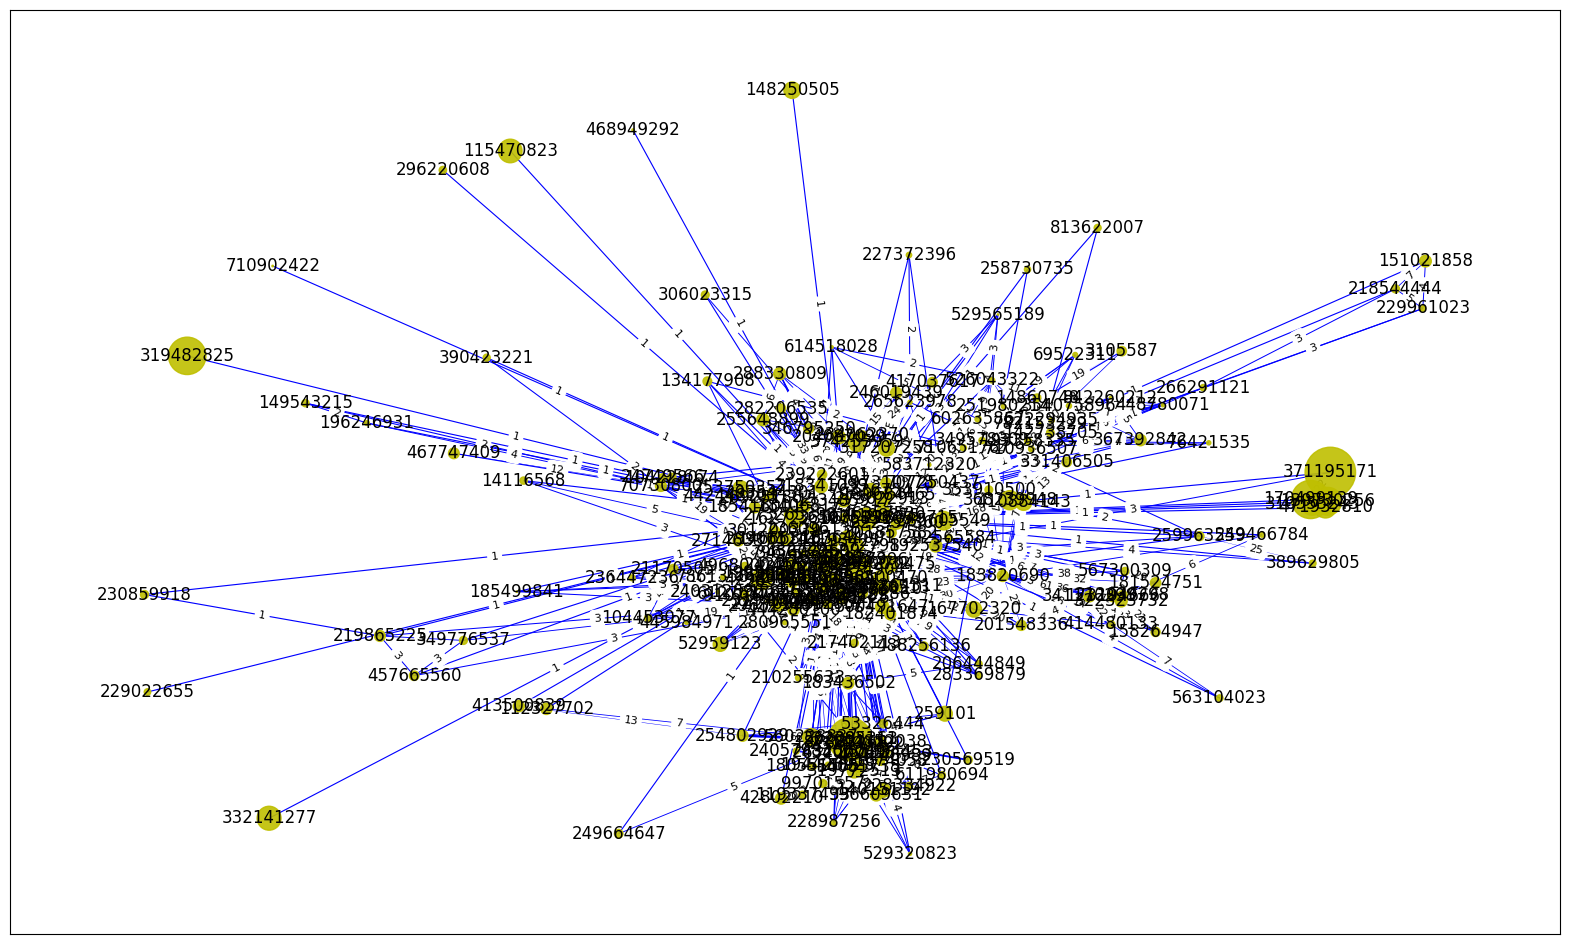

In [314]:
# Рисуем граф связей
plot_graph(G, 5)

**Задание 2.** Провести анализ полученной сети:
* Вывести основные топологические атрибуты (число узлов и ребер графа, среднюю степень узла, диаметр и плотность графа).
* Рассчитать меры центральности: Degree Centrality, Betweenness Centrality, Closeness Centrality, Eigenvector Centrality.
* Рассчитать средний коэффициент кластеризации сети и построить гистограмму распределения коэффициентов кластеризации узлов.
* Попробовать выделить в сети сообщества (любым методом).

[Пример анализа сети](https://networkx.org/nx-guides/content/exploratory_notebooks/facebook_notebook.html)





### Количество узлов

In [112]:
import pickle

# Загрузка объекта из файла
with open("friends_friends.pkl", "rb") as file:
    g = pickle.load(file)

print(f"Загружен объект типа: {type(g)}")
print(f"Содержимое: {g}")

Загружен объект типа: <class 'networkx.classes.digraph.DiGraph'>
Содержимое: DiGraph with 617979 nodes and 1966948 edges


In [113]:
G = g
G_undirected = G.to_undirected()

In [114]:
G.number_of_nodes()

617979

### Количество ребер

In [60]:
G.number_of_edges()

1966948

### Среднее количество ребер

In [63]:
np.mean([d for _, d in G.degree()])

6.365743819773811

### Диаметр

In [ ]:
import random
from collections import deque


def two_sweep_diameter(G_undirected):
    """
    Алгоритм 2-sweep для оценки диаметра графа
    1. BFS от случайной вершины, находим самую дальнюю вершину A
    2. BFS от A, находим самую дальнюю вершину B
    3. Расстояние A-B является нижней границей диаметра
    """

    if not G_undirected.nodes():
        return 0
    print("undirectted")
    # Шаг 1: Выбираем случайную вершину
    nodes = list(G_undirected.nodes())
    start_node = random.choice(nodes)
    # BFS от случайной вершины
    distances1 = bfs(G_undirected, start_node)
    node_a = max(distances1, key=distances1.get)

    # Шаг 2: BFS от самой дальней вершины
    distances2 = bfs(G_undirected, node_a)
    node_b = max(distances2, key=distances2.get)

    diameter = distances2[node_b]

    print(f"Диаметр (2-sweep): {diameter}")
    print(f"Крайние вершины: {node_a} ↔ {node_b}")

    return diameter


def bfs(G, source):
    """BFS возвращает расстояния от source до всех достижимых вершин"""
    distances = {source: 0}
    queue = deque([source])

    while queue:
        node = queue.popleft()
        current_distance = distances[node]

        for neighbor in G.neighbors(node):
            if neighbor not in distances:
                distances[neighbor] = current_distance + 1
                queue.append(neighbor)

    return distances

In [92]:
diameter = two_sweep_diameter(G_undirected)
diameter

undirectted
Диаметр (2-sweep): 6
Крайние вершины: 437539 ↔ 709413


6

### Средняя длина пути

Выполняем BFS от 200 случайных вершин...
  Обработано 10/200 вершин, текущая оценка: 3.128
  Обработано 20/200 вершин, текущая оценка: 3.138
  Обработано 30/200 вершин, текущая оценка: 3.204
  Обработано 40/200 вершин, текущая оценка: 3.106
  Обработано 50/200 вершин, текущая оценка: 3.121
  Обработано 60/200 вершин, текущая оценка: 3.093
  Обработано 70/200 вершин, текущая оценка: 3.071
  Обработано 80/200 вершин, текущая оценка: 3.057
  Обработано 90/200 вершин, текущая оценка: 3.069
  Обработано 100/200 вершин, текущая оценка: 3.072
  Обработано 110/200 вершин, текущая оценка: 3.076
  Обработано 120/200 вершин, текущая оценка: 3.061
  Обработано 130/200 вершин, текущая оценка: 3.071
  Обработано 140/200 вершин, текущая оценка: 3.071
  Обработано 150/200 вершин, текущая оценка: 3.070
  Обработано 160/200 вершин, текущая оценка: 3.075
  Обработано 170/200 вершин, текущая оценка: 3.078
  Обработано 180/200 вершин, текущая оценка: 3.093
  Обработано 190/200 вершин, текущая оценка: 3.085

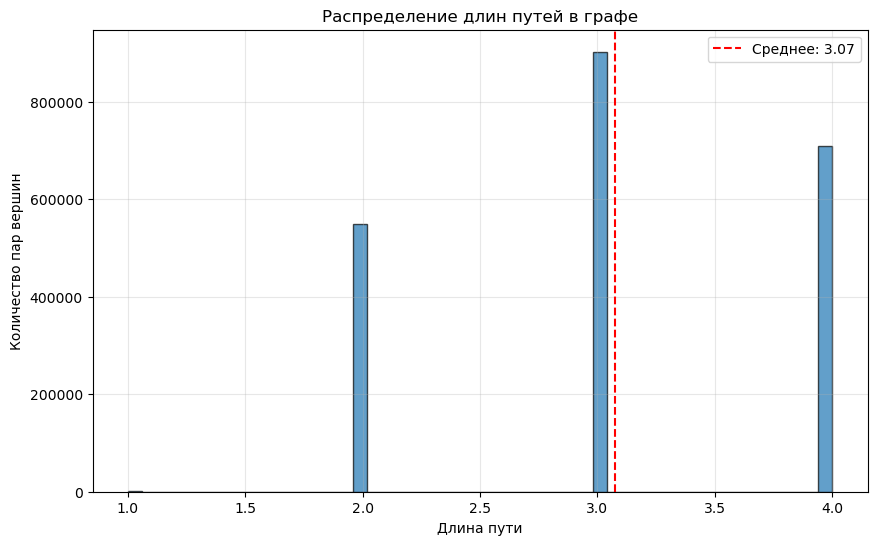

In [93]:
def estimate_average_path_length(G, sample_size=100, max_bfs_nodes=10000):
    """
    Оценка средней длины пути через выборочные BFS

    Parameters:
    -----------
    G : NetworkX Graph
    sample_size : количество случайных вершин для BFS
    max_bfs_nodes : максимальное число вершин в BFS (для ограничения памяти)
    """

    if G.number_of_nodes() == 0:
        return 0

    nodes = list(G.nodes())

    # Если граф слишком большой, берем выборку
    if len(nodes) > sample_size:
        sources = random.sample(nodes, sample_size)
    else:
        sources = nodes

    all_distances = []
    total_pairs = 0

    print(f"Выполняем BFS от {len(sources)} случайных вершин...")

    for i, source in enumerate(sources):
        # BFS от source
        distances = {}
        queue = deque([source])
        distances[source] = 0
        nodes_visited = 0

        while queue and nodes_visited < max_bfs_nodes:
            node = queue.popleft()
            current_dist = distances[node]

            for neighbor in G.neighbors(node):
                if neighbor not in distances:
                    distances[neighbor] = current_dist + 1
                    queue.append(neighbor)
                    nodes_visited += 1

        # Собираем расстояния (исключаем 0 - расстояние до себя)
        dist_values = [d for d in distances.values() if d > 0]

        if dist_values:
            all_distances.extend(dist_values)
            total_pairs += len(dist_values)

        if (i + 1) % 10 == 0:
            avg_so_far = np.mean(all_distances) if all_distances else 0
            print(f"  Обработано {i + 1}/{len(sources)} вершин, текущая оценка: {avg_so_far:.3f}")

    if not all_distances:
        return 0

    # Вычисляем среднее
    avg_path_length = np.mean(all_distances)
    std_path_length = np.std(all_distances)

    print("\nРезультаты:")
    print(f"  Средняя длина пути: {avg_path_length:.3f}")
    print(f"  Стандартное отклонение: {std_path_length:.3f}")
    print(f"  Минимальная длина: {np.min(all_distances)}")
    print(f"  Максимальная длина: {np.max(all_distances)}")
    print(f"  Всего пар вершин: {total_pairs}")

    # Гистограмма распределения
    if len(all_distances) > 0:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 6))
        plt.hist(all_distances, bins=50, alpha=0.7, edgecolor="black")
        plt.axvline(
            avg_path_length, color="red", linestyle="--", label=f"Среднее: {avg_path_length:.2f}"
        )
        plt.xlabel("Длина пути")
        plt.ylabel("Количество пар вершин")
        plt.title("Распределение длин путей в графе")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    return avg_path_length


# Использование
avg_path = estimate_average_path_length(G_undirected, sample_size=200)

### Плотность графа

In [96]:
nx.density(G)

5.150461521100922e-06

## Меры центральности

In [109]:
degree_centrality = nx.centrality.degree_centrality(
    G_undirected
)  # save results in a variable to use again
(sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True))[:8]

[(1776006, 0.01605073319762192),
 (2018085, 0.01588406059762645),
 (1894744, 0.014757806912220176),
 (1759235, 0.013854862147196178),
 (1735500, 0.012982662813239306),
 (1993855, 0.011702681972497402),
 (1674667, 0.011680027444342678),
 (1924894, 0.011417882189980872)]

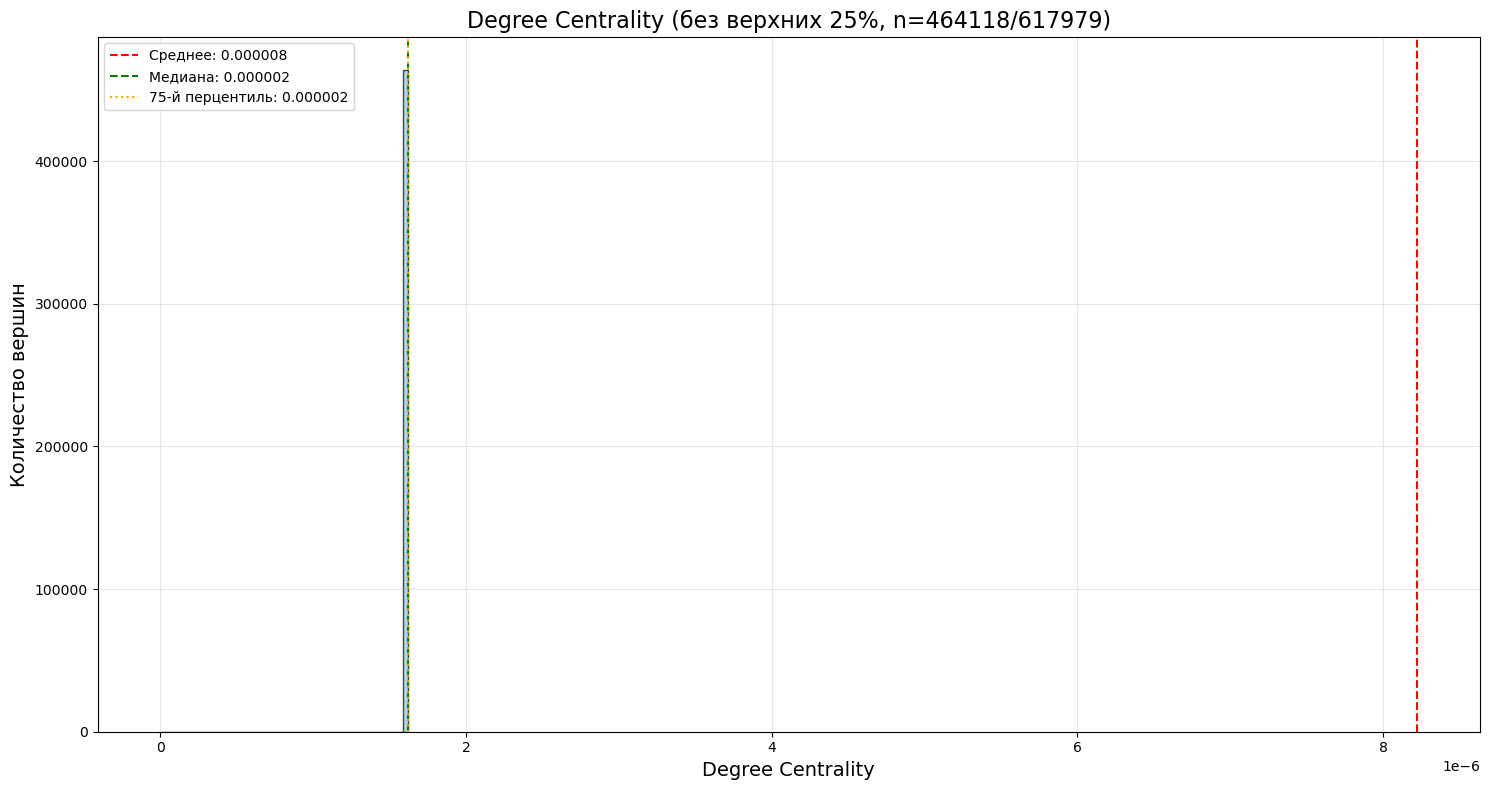

Всего вершин: 617979
После фильтрации: 464118 (75.1%)
Среднее: 0.000008
Медиана: 0.000002
75-й перцентиль: 0.000002


In [136]:
values = list(degree_centrality.values())

if values:
    # Фильтруем верхние 25%
    q75 = np.percentile(values, 30)
    filtered_values = [v for v in values if v <= q75]

    # Строим график
    plt.figure(figsize=(15, 8))
    plt.hist(filtered_values, bins=50, alpha=0.7, color="skyblue", edgecolor="black")

    # Добавляем статистические линии
    plt.axvline(
        np.mean(values), color="red", linestyle="--", label=f"Среднее: {np.mean(values):.6f}"
    )
    plt.axvline(
        np.median(values), color="green", linestyle="--", label=f"Медиана: {np.median(values):.6f}"
    )
    plt.axvline(q75, color="orange", linestyle=":", label=f"75-й перцентиль: {q75:.6f}")

    plt.title(
        f"Degree Centrality (без верхних 25%, n={len(filtered_values)}/{len(values)})", fontsize=16
    )
    plt.xlabel("Degree Centrality", fontsize=14)
    plt.ylabel("Количество вершин", fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Статистика
    print(f"Всего вершин: {len(values)}")
    print(
        f"После фильтрации: {len(filtered_values)} ({len(filtered_values) / len(values) * 100:.1f}%)"
    )
    print(f"Среднее: {np.mean(values):.6f}")
    print(f"Медиана: {np.median(values):.6f}")
    print(f"75-й перцентиль: {q75:.6f}")
else:
    print("Нет данных")

In [137]:
np.mean(values)

8.222998591776247e-06

In [116]:
def approximate_betweenness(G, k=None, normalized=True, seed=None):
    """
    Приближенный расчет betweenness centrality
    Использует выборку k случайных вершин

    Parameters:
    -----------
    G : NetworkX граф
    k : количество случайных вершин для выборки
    normalized : нормализовать ли результат
    seed : seed для воспроизводимости
    """

    n = G.number_of_nodes()

    # Если k не указано, используем эвристику
    if k is None:
        # Эвристика: для графов > 1000 вершин используем 10%
        k = min(1000, max(100, int(n * 0.1)))

    k = min(k, n)  # Не больше общего числа вершин

    print("Приближенный расчет betweenness centrality")
    print(f"Граф: {n} вершин, {G.number_of_edges()} ребер")
    print(f"Используем выборку из {k} вершин ({k / n * 100:.1f}%)")

    # Приближенный алгоритм
    betweenness = nx.betweenness_centrality(
        G,
        k=k,  # Ключевой параметр!
        normalized=normalized,
        seed=seed,
        endpoints=False,  # Ускоряет расчет
    )

    return betweenness

In [117]:
approx_betweenness = approximate_betweenness(G_undirected, k=500)

# Топ-8 вершин
top_betweenness = sorted(approx_betweenness.items(), key=lambda x: x[1], reverse=True)[:8]

Приближенный расчет betweenness centrality
Граф: 617979 вершин, 1570171 ребер
Используем выборку из 500 вершин (0.1%)


In [141]:
approx_betweenness.values()

dict_values([0.021650026630821082, 2.2005163086759355e-05, 1.668829730378699e-05, 7.170277283323075e-05, 3.2806182525704705e-06, 8.619358418741633e-06, 0.0008956314186729786, 3.539554635314402e-05, 0.00011844230687614413, 7.819455063820547e-05, 5.7440730586964805e-05, 3.965873158226736e-05, 2.609412184334919e-05, 0.0007467491229813677, 2.3794788222093315e-05, 0.00020910223723530453, 0.0002020898262888683, 3.761896796781958e-05, 3.8033768069145006e-06, 2.3941202355928807e-05, 5.810984485214974e-05, 0.0009891703856821164, 6.23985124273713e-05, 3.6757617822229615e-05, 5.357188107145158e-05, 4.314892947089818e-05, 7.476125549853571e-05, 4.772598420834307e-06, 0.0002287814666395317, 0.0002854376049894467, 0.0003126380498476078, 0.00012957486119068764, 7.695051193259863e-05, 4.3376624839898585e-05, 0.00032392195821998965, 1.878617188333334e-05, 0.001613589171743276, 2.153215912195876e-05, 3.140516502749414e-05, 0.0002283656877865306, 0.00011373971539129463, 5.9225429186570136e-05, 2.43604502

In [155]:
count = 0
cent = 0
for node, centrality in sorted(approx_betweenness.items(), key=lambda x: x[1], reverse=True):
    count += 1
    cent += centrality
print(cent / count)

6.030233407012643e-06


Text(0, 0.5, 'Counts')

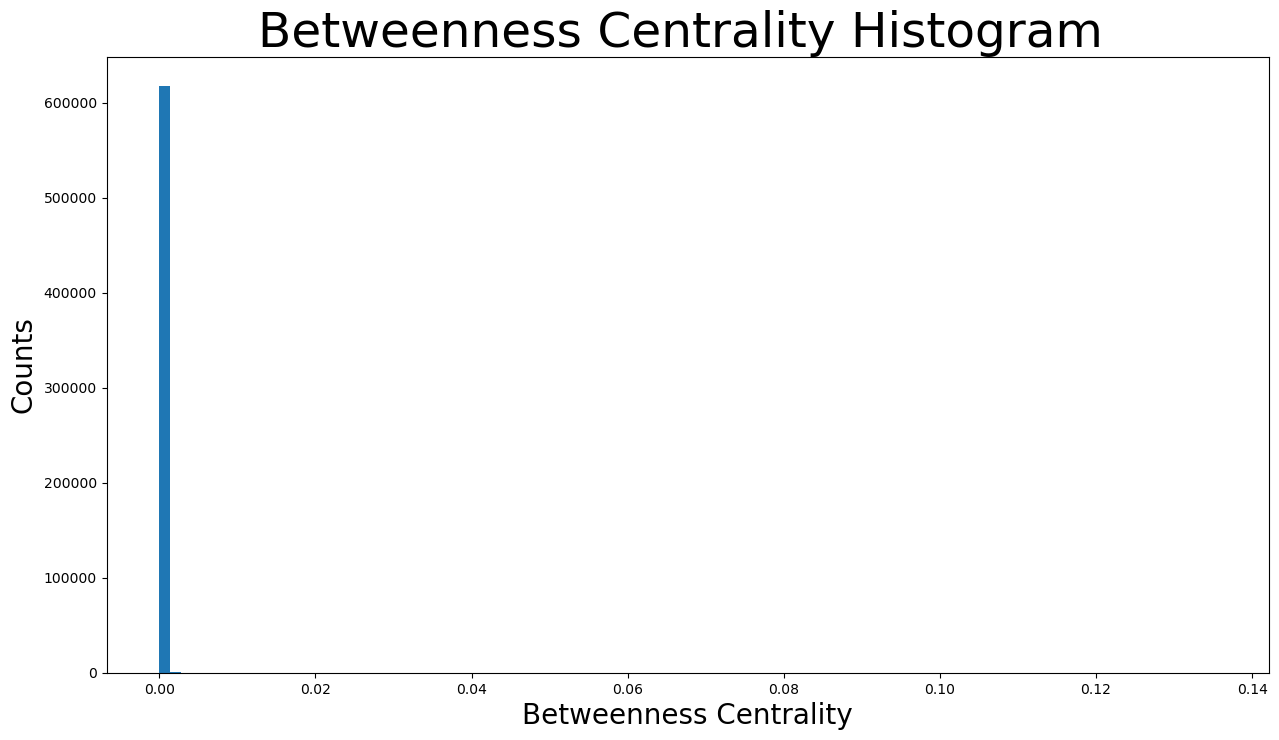

In [118]:
plt.figure(figsize=(15, 8))
plt.hist(approx_betweenness.values(), bins=100)
plt.title("Betweenness Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Betweenness Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

In [119]:
def approximate_closeness(G, k=None, normalized=True):
    """
    Приближенный расчет closeness centrality через выборку

    Parameters:
    -----------
    G : NetworkX граф
    k : количество случайных вершин для BFS (None = автовыбор)
    normalized : нормализовать результат
    """

    n = G.number_of_nodes()

    # Автоматический выбор k
    if k is None:
        if n <= 1000:
            k = n  # для маленьких графов считаем точно
        else:
            # Эвристика: sqrt(n) или максимум 1000
            k = min(1000, int(np.sqrt(n)))

    k = min(k, n)

    print("Приближенный closeness centrality")
    print(f"Граф: {n} вершин, {G.number_of_edges()} ребер")
    print(f"Используем BFS от {k} вершин ({k / n * 100:.1f}%)")

    closeness = {}

    # Выбираем случайные вершины
    nodes = list(G.nodes())
    if k < n:
        sampled_nodes = random.sample(nodes, k)
    else:
        sampled_nodes = nodes

    # Предварительные вычисления
    reachable_counts = {}
    total_distances = {}

    for i, source in enumerate(sampled_nodes):
        # BFS от source
        distances = {}
        queue = deque([source])
        distances[source] = 0

        while queue:
            node = queue.popleft()
            current_dist = distances[node]

            for neighbor in G.neighbors(node):
                if neighbor not in distances:
                    distances[neighbor] = current_dist + 1
                    queue.append(neighbor)

        # Обновляем статистику
        for node, dist in distances.items():
            if node not in reachable_counts:
                reachable_counts[node] = 0
                total_distances[node] = 0

            if dist > 0:  # исключаем расстояние до себя
                reachable_counts[node] += 1
                total_distances[node] += dist

        if (i + 1) % 10 == 0 and k > 50:
            print(f"  Обработано {i + 1}/{k} BFS")

    # Вычисляем closeness для всех вершин
    for node in nodes:
        reachable = reachable_counts.get(node, 0)
        total_dist = total_distances.get(node, 0)

        if reachable > 0 and total_dist > 0:
            # Среднее расстояние до достижимых вершин
            avg_distance = total_dist / reachable

            # Closeness = 1 / среднее_расстояние
            c = 1.0 / avg_distance if avg_distance > 0 else 0

            # Масштабируем на основе выборки
            if k < n:
                # Оцениваем общее количество достижимых вершин
                estimated_reachable = (reachable / k) * (n - 1)
                if estimated_reachable > 0:
                    c = c * (reachable / k)  # корректировка
        else:
            c = 0

        closeness[node] = c

    # Нормализация (если нужно)
    if normalized and closeness:
        max_val = max(closeness.values())
        if max_val > 0:
            closeness = {node: c / max_val for node, c in closeness.items()}

    return closeness

In [ ]:
print("🚀 Быстрый приближенный closeness centrality...")
approx_closeness = approximate_closeness(G_undirected, k=500)

# Топ-8 вершин
top_closeness = sorted(approx_closeness.items(), key=lambda x: x[1], reverse=True)[:8]

🚀 Быстрый приближенный closeness centrality...
Приближенный closeness centrality
Граф: 617979 вершин, 1570171 ребер
Используем BFS от 500 вершин (0.1%)
  Обработано 10/500 BFS
  Обработано 20/500 BFS
  Обработано 30/500 BFS
  Обработано 40/500 BFS
  Обработано 50/500 BFS
  Обработано 60/500 BFS
  Обработано 70/500 BFS
  Обработано 80/500 BFS
  Обработано 90/500 BFS
  Обработано 100/500 BFS
  Обработано 110/500 BFS
  Обработано 120/500 BFS
  Обработано 130/500 BFS
  Обработано 140/500 BFS
  Обработано 150/500 BFS
  Обработано 160/500 BFS
  Обработано 170/500 BFS
  Обработано 180/500 BFS
  Обработано 190/500 BFS
  Обработано 200/500 BFS
  Обработано 210/500 BFS
  Обработано 220/500 BFS
  Обработано 230/500 BFS
  Обработано 240/500 BFS
  Обработано 250/500 BFS
  Обработано 260/500 BFS
  Обработано 270/500 BFS
  Обработано 280/500 BFS
  Обработано 290/500 BFS
  Обработано 300/500 BFS
  Обработано 310/500 BFS
  Обработано 320/500 BFS
  Обработано 330/500 BFS
  Обработано 340/500 BFS
  Обраб

In [154]:
count = 0
cent = 0
for node, centrality in sorted(approx_closeness.items(), key=lambda x: x[1], reverse=True):
    count += 1
    cent += centrality
print(cent / count)

0.6454945522020187


Text(0, 0.5, 'Counts')

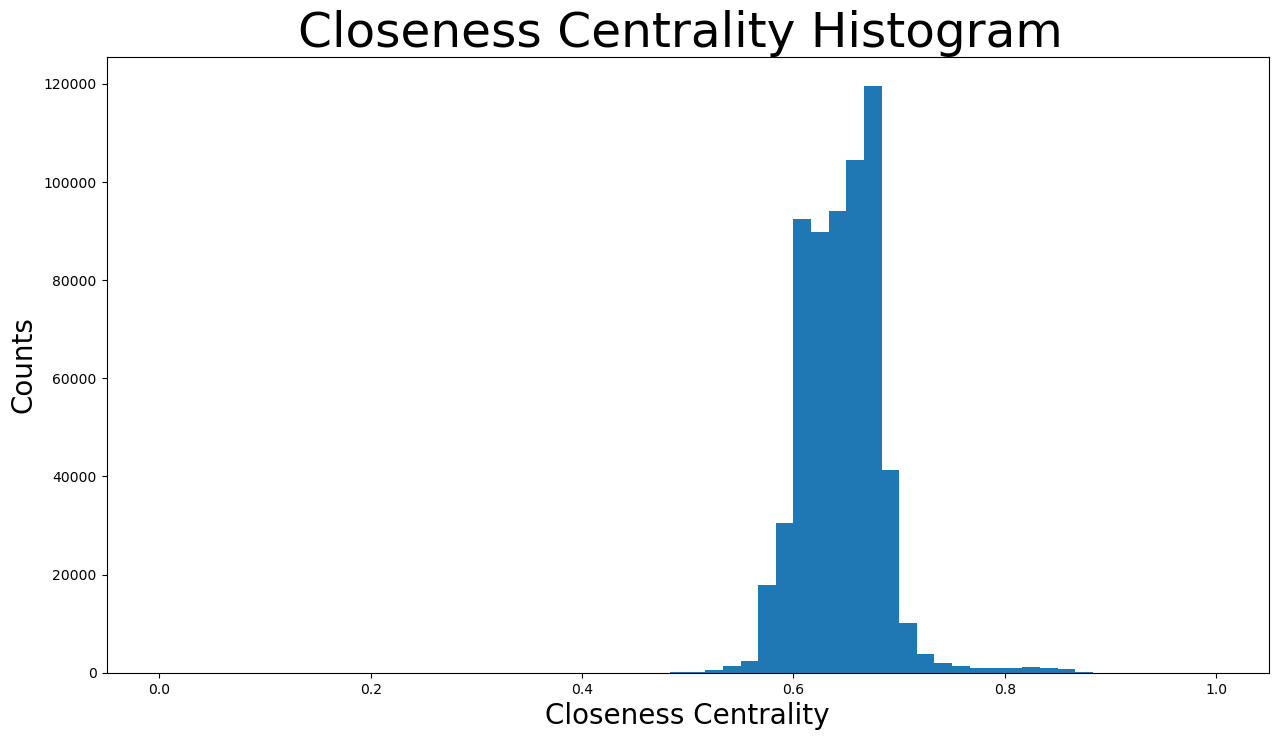

In [151]:
plt.figure(figsize=(15, 8))
plt.hist(approx_closeness.values(), bins=60)
plt.title("Closeness Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Closeness Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

In [122]:
from scipy import sparse


def fast_eigenvector_centrality(G, max_iter=100, tol=1.0e-6, normalized=True):
    """
    Быстрый расчет eigenvector centrality через степенной метод

    Parameters:
    -----------
    G : NetworkX граф
    max_iter : максимальное количество итераций
    tol : допустимая погрешность
    normalized : нормализовать результат
    """

    n = G.number_of_nodes()
    if n == 0:
        return {}

    print(f"Быстрый eigenvector centrality: {n} вершин")

    # Преобразуем в матрицу смежности
    nodes = list(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    # Создаем разреженную матрицу смежности
    row_indices = []
    col_indices = []

    for u, v in G.edges():
        i, j = node_to_idx[u], node_to_idx[v]
        row_indices.extend([i, j])
        col_indices.extend([j, i])

    # Создаем разреженную матрицу
    A = sparse.csr_matrix(
        (np.ones(len(row_indices)), (row_indices, col_indices)), shape=(n, n), dtype=np.float64
    )

    # Инициализируем вектор
    x = np.ones(n) / np.sqrt(n)

    # Степенной метод
    for iteration in range(max_iter):
        x_old = x.copy()

        # Умножение: x = A * x
        x = A.dot(x)

        # Нормализация
        norm = np.linalg.norm(x)
        if norm == 0:
            x = np.ones(n) / np.sqrt(n)
        else:
            x = x / norm

        # Проверка сходимости
        diff = np.linalg.norm(x - x_old)
        if diff < tol:
            print(f"  Сходимость за {iteration + 1} итераций")
            break

        if (iteration + 1) % 20 == 0:
            print(f"  Итерация {iteration + 1}, разница: {diff:.2e}")

    else:
        print(f"  Достигнут лимит {max_iter} итераций")

    # Преобразуем в словарь
    eigenvector = {nodes[i]: float(x[i]) for i in range(n)}

    # Нормализация (если нужно)
    if normalized and eigenvector:
        max_val = max(eigenvector.values())
        if max_val > 0:
            eigenvector = {node: val / max_val for node, val in eigenvector.items()}

    return eigenvector

In [123]:
# Быстрое использование
print("🚀 Быстрый eigenvector centrality...")
eigen_fast = fast_eigenvector_centrality(G_undirected, max_iter=50)

# Топ-8 вершин
top_eigen = sorted(eigen_fast.items(), key=lambda x: x[1], reverse=True)[:8]

print("\nТоп-8 вершин по eigenvector centrality:")
for node, centrality in top_eigen:
    print(f"  Вершина {node}: {centrality:.6f}")

🚀 Быстрый eigenvector centrality...
Быстрый eigenvector centrality: 617979 вершин
  Итерация 20, разница: 7.50e-01
  Итерация 40, разница: 7.49e-01
  Достигнут лимит 50 итераций

Топ-8 вершин по eigenvector centrality:
  Вершина 436030: 1.000000
  Вершина 436891: 0.998730
  Вершина 436007: 0.927238
  Вершина 436006: 0.909277
  Вершина 437374: 0.836532
  Вершина 438263: 0.793275
  Вершина 437136: 0.786147
  Вершина 437203: 0.780566


In [149]:
count = 0
centrality_all = 0
for node, centrality in sorted(eigen_fast.items(), key=lambda x: x[1], reverse=True):
    centrality_all += centrality
    count += 1
print(centrality_all / count)

0.0018528413423276222


Text(0, 0.5, 'Counts')

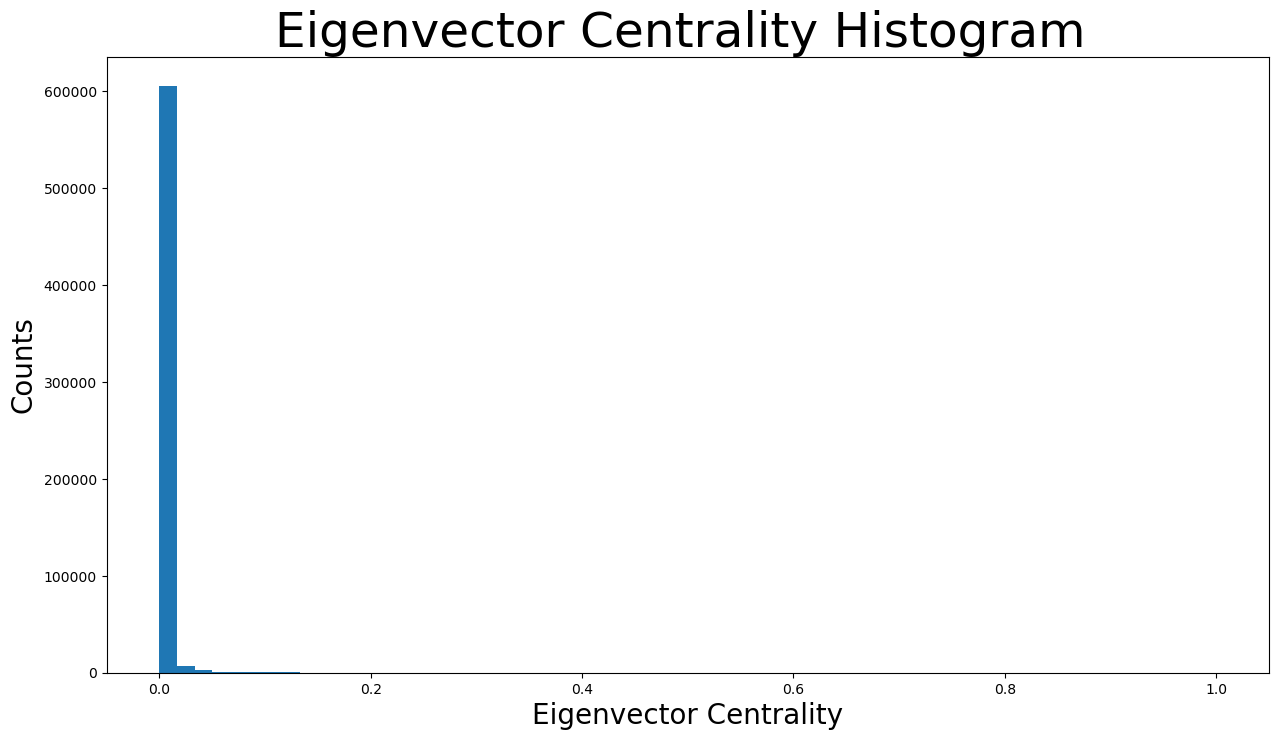

In [124]:
plt.figure(figsize=(15, 8))
plt.hist(eigen_fast.values(), bins=60)
# plt.xticks(ticks=[0, 0.01, 0.02, 0.04, 0.06, 0.08])  # set the x axis ticks
plt.title("Eigenvector Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Eigenvector Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

## Коэффициент кластеризации сети

In [125]:
nx.average_clustering(G)

1.5592536485115395e-05

Text(0, 0.5, 'Counts')

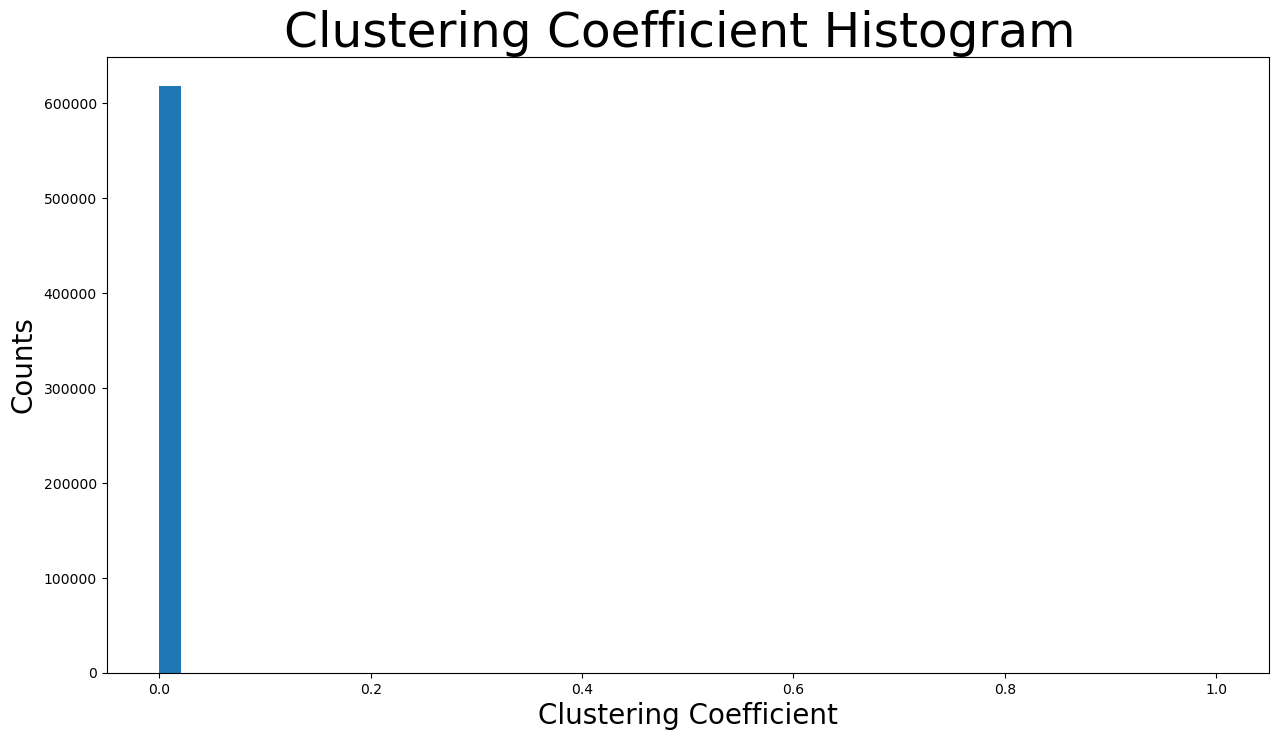

In [126]:
plt.figure(figsize=(15, 8))
plt.hist(nx.clustering(G).values(), bins=50)
plt.title("Clustering Coefficient Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Clustering Coefficient", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

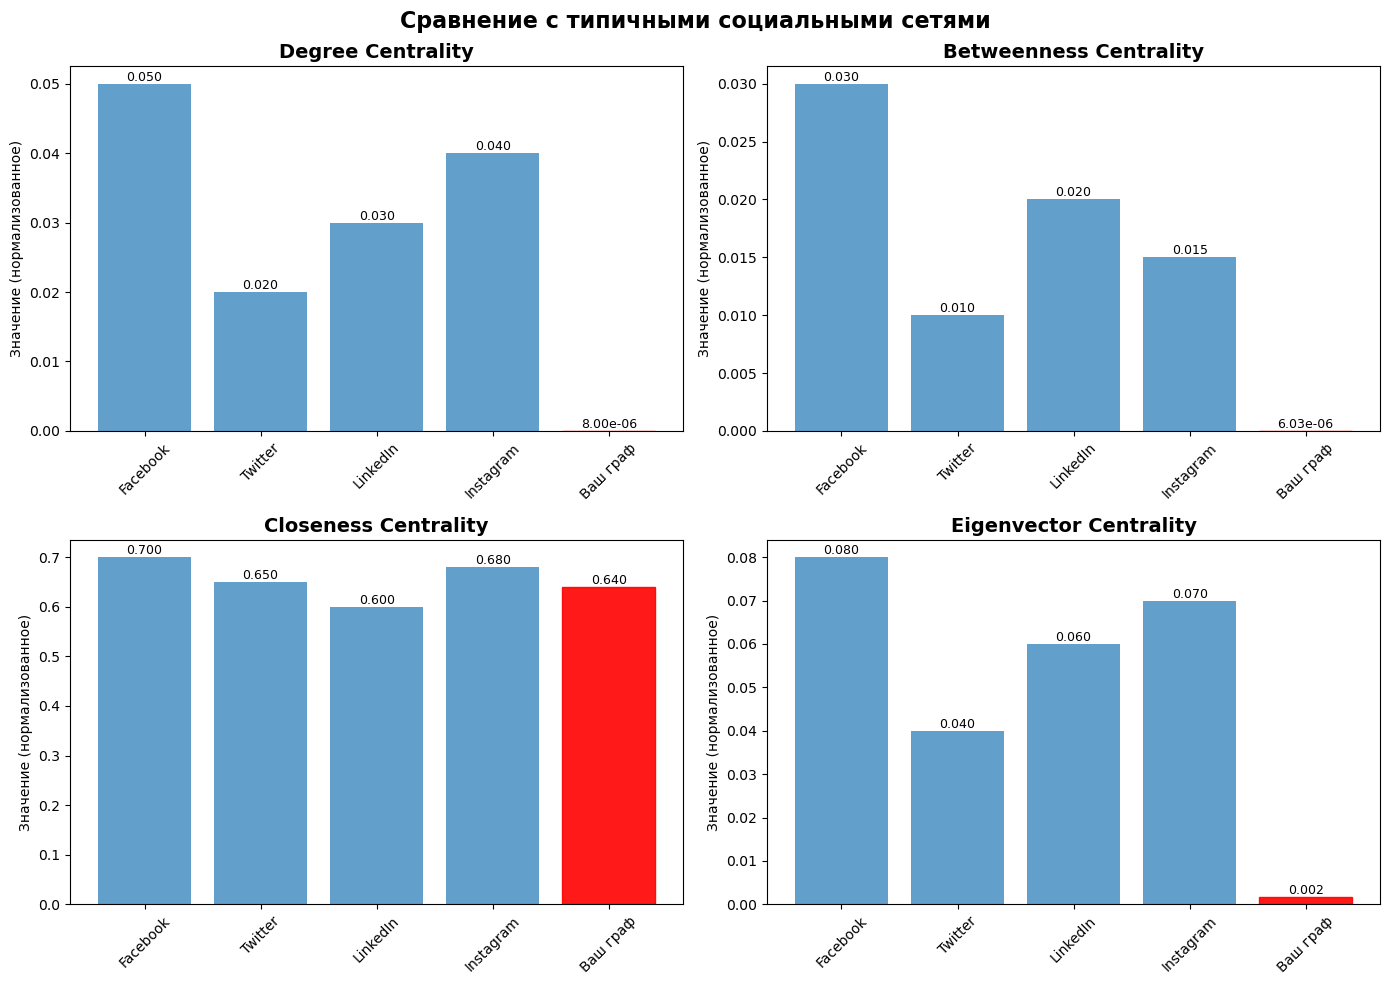

In [156]:
typical_values = {
    "Facebook": {"Degree": 0.05, "Betweenness": 0.03, "Closeness": 0.70, "Eigenvector": 0.08},
    "Twitter": {"Degree": 0.02, "Betweenness": 0.01, "Closeness": 0.65, "Eigenvector": 0.04},
    "LinkedIn": {"Degree": 0.03, "Betweenness": 0.02, "Closeness": 0.60, "Eigenvector": 0.06},
    "Instagram": {"Degree": 0.04, "Betweenness": 0.015, "Closeness": 0.68, "Eigenvector": 0.07},
    "Ваш граф": {
        "Degree": 0.000008,
        "Betweenness": 0.00000603,
        "Closeness": 0.64,
        "Eigenvector": 0.0018,
    },
}

# Визуализация сравнения
metrics = ["Degree", "Betweenness", "Closeness", "Eigenvector"]
networks = list(typical_values.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    values = [typical_values[network][metric] for network in networks]

    bars = axes[i].bar(networks, values, alpha=0.7)
    axes[i].set_title(f"{metric} Centrality", fontsize=14, fontweight="bold")
    axes[i].set_ylabel("Значение (нормализованное)")
    axes[i].tick_params(axis="x", rotation=45)

    # Выделяем ваш граф
    your_idx = networks.index("Ваш граф")
    bars[your_idx].set_color("red")
    bars[your_idx].set_alpha(0.9)

    # Добавляем значения на столбцы
    for bar, val in zip(bars, values):
        height = bar.get_height()
        if metric in ["Degree", "Betweenness", "Eigenvector"]:
            axes[i].text(
                bar.get_x() + bar.get_width() / 2.0,
                height,
                f"{val:.2e}" if val < 0.001 else f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
        else:
            axes[i].text(
                bar.get_x() + bar.get_width() / 2.0,
                height,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

plt.suptitle("Сравнение с типичными социальными сетями", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Сообщества

In [130]:
G = G_undirected
colors = ["" for x in range(G.number_of_nodes())]
counter = 0
for com in nx.community.label_propagation_communities(G_undirected):
    color = f"#{randint(0, 0xFFFFFF):06X}"
    counter += 1
    for node in com:
        colors[list(G.nodes).index(node)] = color
counter

973

KeyboardInterrupt: 

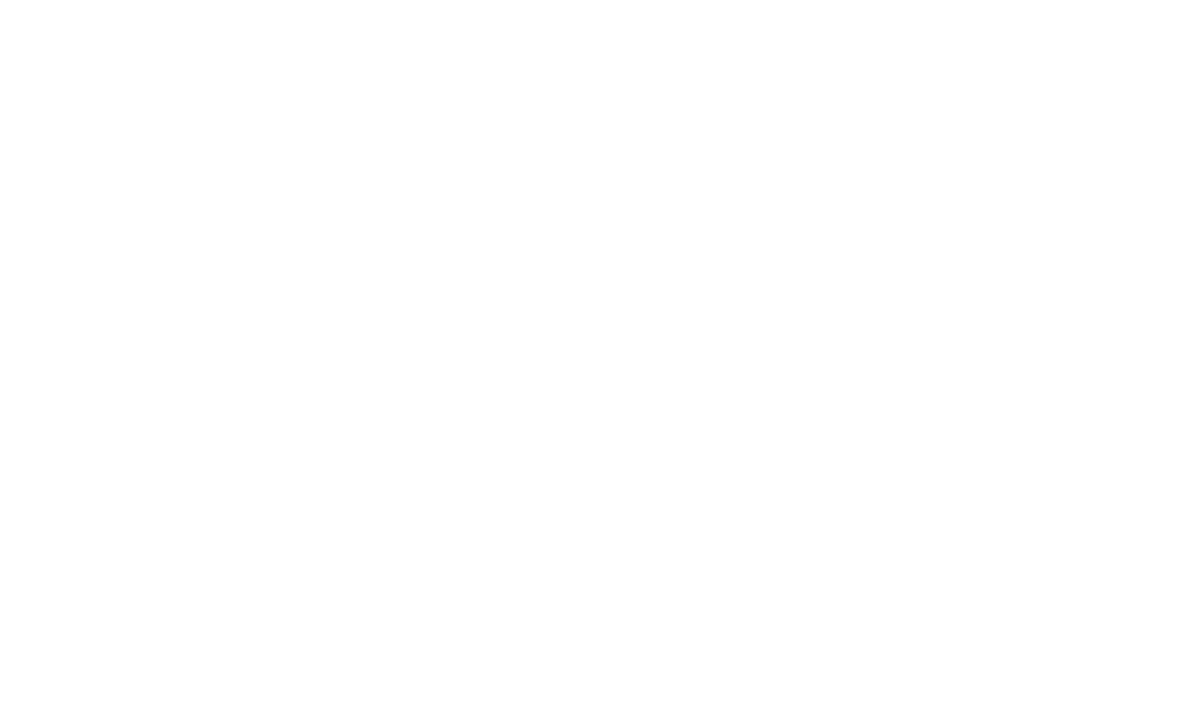

In [157]:
plt.figure(figsize=(15, 9))
plt.axis("off")
pos = nx.spring_layout(g, k=0.1)
nx.draw_networkx(G, pos=pos, node_size=10, with_labels=False, width=0.15, node_color=colors)

In [161]:
cursor.execute("""SELECT c.*
FROM creator c
LEFT JOIN sub s1 ON c.id = s1.subscriber
LEFT JOIN sub s2 ON c.id = s2.contentmaker
WHERE s1.subscriber IS NULL
  AND s2.contentmaker IS NULL
ORDER BY c.id""")
cursor.fetchall()

[(404916, 212, True, 1), (1901073, 816, True, 1)]

In [167]:
G.remove_node(1901108)
G.remove_node(1901109)
G.remove_node(1901110)
G.remove_node(1901111)
G.remove_node(1901112)

In [166]:
if nx.is_connected(G):
    print("✓ Граф связный")
else:
    components = list(nx.connected_components(G))
    print(f"✗ Граф несвязный, {len(components)} компонент")

    # Размеры компонент
    for i, comp in enumerate(sorted(components, key=len, reverse=True)[:5], 1):
        print(f"{i}. {len(comp):,} вершин")

✗ Граф несвязный, 2 компонент
1. 617,972 вершин
2. 5 вершин


In [168]:
colors = ["" for x in range(G.number_of_nodes())]
counter = 0
for com in nx.community.asyn_fluidc(G, 8, seed=0):
    color = f"#{randint(0, 0xFFFFFF):06X}"  # creates random RGB color
    counter += 1
    for node in com:
        colors[list(G.nodes).index(node)] = color
counter

8

In [ ]:
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx

# 1. Создайте мета-граф, где каждая нода — сообщество
community_nodes = defaultdict(list)
for com in nx.community.asyn_fluidc(G, 8, seed=0):
    for node in com:
        community_nodes[id(com)].append(node)

# 2. Создайте новый граф H
H = nx.Graph()
for com_id, nodes in community_nodes.items():
    H.add_node(com_id, size=len(nodes), nodes=nodes)

# 3. Добавьте рёбра между сообществами (по связям между их узлами)
edges_between = defaultdict(int)
for u, v in G.edges():
    u_com = None
    v_com = None
    # Найдем, к каким сообществам принадлежат u и v
    for com_id, nodes in community_nodes.items():
        if u in nodes:
            u_com = com_id
        if v in nodes:
            v_com = com_id
    if u_com != v_com and u_com and v_com:
        edges_between[(u_com, v_com)] += 1

for (com1, com2), weight in edges_between.items():
    H.add_edge(com1, com2, weight=weight)

# 4. Визуализируйте мета-граф
pos = nx.spring_layout(H, seed=42)
node_sizes = [H.nodes[n]["size"] / 100 for n in H.nodes()]  # Масштабируем
edge_widths = [H[u][v]["weight"] / 100 for u, v in H.edges()]

nx.draw(
    H,
    pos,
    node_size=node_sizes,
    node_color="lightblue",
    width=edge_widths,
    with_labels=True,
    font_size=8,
)
plt.title("Мета-граф сообществ (600k узлов -> 8 сообществ)")
plt.show()